In [1]:
import torch
from h5py import File as HDF5File

# Load dataset and device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
jet_images_path = '../data/jet-images_Mass60-100_pT250-300_R1.25_Pix25.hdf5'
jet_mass_data = HDF5File(jet_images_path, 'r')

print(jet_mass_data.keys())
print(jet_mass_data['image'].shape)

<KeysViewHDF5 ['image', 'jet_delta_R', 'jet_eta', 'jet_mass', 'jet_phi', 'jet_pt', 'signal', 'tau_1', 'tau_2', 'tau_21', 'tau_3', 'tau_32']>
(872666, 25, 25)


In [2]:
# from HEPGAN.preprocessing import DataMaker

# # Define variable and dataset
# batch_size = 128

# # Returns dataset plus kde and smote sampling datasets
# datasets    = DataMaker(jet_mass_data, batch_size = batch_size)

# torch.save({
#     "datasets": datasets
# }, "datasets.pt")

In [3]:
#### Run the cell above this once, then comment back out and use the cell below

from torch.utils.data import DataLoader
batch_size = 128

# Options
sampler = "smote"
sampler = "kde"

train_on = "signal"
train_on = "background"
train_on = "both"

saved = torch.load("datasets.pt")["datasets"]
dataset = saved[f"dataset_{train_on}"]
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

if sampler == "smote":
    sample_dataset = saved[f"smoteSampler_{train_on}"]
    sampleloader = DataLoader(sample_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    
if sampler == "kde":
    sampleloader = saved[f"kdeSampler_{train_on}"]
    
print("Number of samples:", len(dataset))
print("Image shape:", dataset.images.shape)
print("Feature shape:", dataset.features.shape)

Number of samples: 8726
Image shape: torch.Size([8726, 16, 16])
Feature shape: torch.Size([8726, 9])


In [4]:
from HEPGAN.train import train
from HEPGAN.models import InitializeModel
from HEPGAN.loadSaveEval import eval_model, save, load

# Choose model and hyperparameters
model_type = "classical"
# model_type = "StronglyEntangling"
# model_type = "RandomLayer"

sigma = 0.1
n_epochs = 5
lr = .01

In [5]:
#### Initialize, train, and evaluate model
model = InitializeModel(model_type = model_type, sigma = sigma)

Device: cuda
Starting training on device: cuda
[Epoch 1/5] [Avg D loss: 0.2092] [Avg G loss: 1.2798]


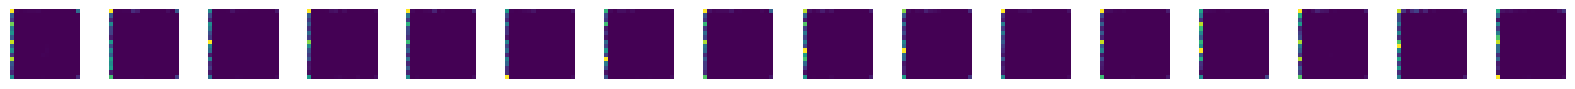


========== EPOCH STAT BREAKDOWN ==========
Avg validity_loss   : 1.0293
Avg stat_loss       : 0.0123
  avg_dR_mean       : 0.0060
  avg_dR_std        : 0.0047
  avg_pix_mean      : 0.0009
  avg_pix_std       : 0.0006
Avg nnz_loss        : 0.2382

------- Final Batch (weighted into g_loss) -------
α = 0.15 ; β = 0.035 ; χ = 3e-05
Last batch validity_loss: 0.3573
Last batch stat_loss:     0.0003
  dR_mean:   0.0062
  dR_std:    0.0013
  pix_mean:  0.0009
  pix_std:   0.0001
Last batch nnz_loss:      0.0000
Total g_loss = 2.3924

[Epoch 2/5] [Avg D loss: 0.1391] [Avg G loss: 2.7677]


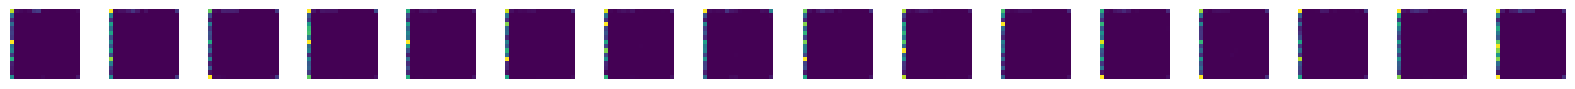


========== EPOCH STAT BREAKDOWN ==========
Avg validity_loss   : 2.7558
Avg stat_loss       : 0.0102
  avg_dR_mean       : 0.0067
  avg_dR_std        : 0.0020
  avg_pix_mean      : 0.0013
  avg_pix_std       : 0.0002
Avg nnz_loss        : 0.0017

------- Final Batch (weighted into g_loss) -------
α = 0.15 ; β = 0.035 ; χ = 3e-05
Last batch validity_loss: 0.4898
Last batch stat_loss:     0.0004
  dR_mean:   0.0070
  dR_std:    0.0026
  pix_mean:  0.0017
  pix_std:   0.0004
Last batch nnz_loss:      0.0000
Total g_loss = 3.2785

[Epoch 3/5] [Avg D loss: 0.1279] [Avg G loss: 4.0103]


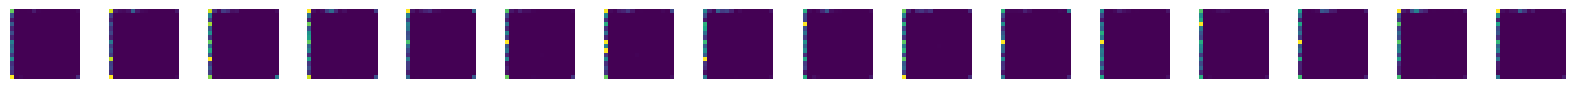


========== EPOCH STAT BREAKDOWN ==========
Avg validity_loss   : 3.9950
Avg stat_loss       : 0.0137
  avg_dR_mean       : 0.0076
  avg_dR_std        : 0.0034
  avg_pix_mean      : 0.0022
  avg_pix_std       : 0.0005
Avg nnz_loss        : 0.0016

------- Final Batch (weighted into g_loss) -------
α = 0.15 ; β = 0.035 ; χ = 3e-05
Last batch validity_loss: 0.7118
Last batch stat_loss:     0.0005
  dR_mean:   0.0077
  dR_std:    0.0043
  pix_mean:  0.0027
  pix_std:   0.0008
Last batch nnz_loss:      0.0000
Total g_loss = 4.7621

[Epoch 4/5] [Avg D loss: 0.1224] [Avg G loss: 5.2213]


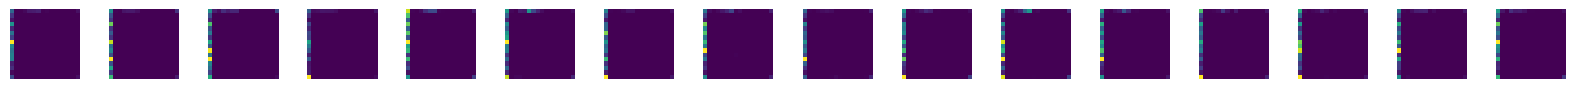


========== EPOCH STAT BREAKDOWN ==========
Avg validity_loss   : 5.2017
Avg stat_loss       : 0.0180
  avg_dR_mean       : 0.0080
  avg_dR_std        : 0.0053
  avg_pix_mean      : 0.0034
  avg_pix_std       : 0.0012
Avg nnz_loss        : 0.0016

------- Final Batch (weighted into g_loss) -------
α = 0.15 ; β = 0.035 ; χ = 3e-05
Last batch validity_loss: 0.8574
Last batch stat_loss:     0.0007
  dR_mean:   0.0080
  dR_std:    0.0066
  pix_mean:  0.0041
  pix_std:   0.0017
Last batch nnz_loss:      0.0000
Total g_loss = 5.7377

[Epoch 5/5] [Avg D loss: 0.1187] [Avg G loss: 5.2929]


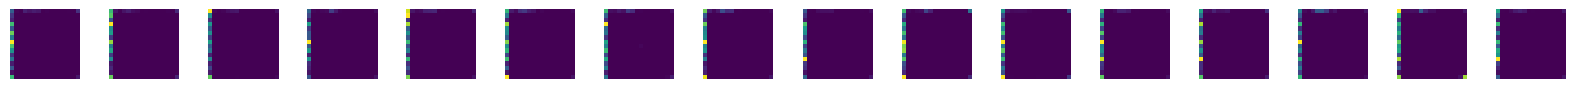


========== EPOCH STAT BREAKDOWN ==========
Avg validity_loss   : 5.2685
Avg stat_loss       : 0.0228
  avg_dR_mean       : 0.0084
  avg_dR_std        : 0.0072
  avg_pix_mean      : 0.0049
  avg_pix_std       : 0.0023
Avg nnz_loss        : 0.0016

------- Final Batch (weighted into g_loss) -------
α = 0.15 ; β = 0.035 ; χ = 3e-05
Last batch validity_loss: 0.7788
Last batch stat_loss:     0.0009
  dR_mean:   0.0083
  dR_std:    0.0079
  pix_mean:  0.0055
  pix_std:   0.0031
Last batch nnz_loss:      0.0000
Total g_loss = 5.2186



In [6]:
train(model = model, dataloader = dataloader, sampleloader = sampleloader, n_epochs = n_epochs, lr = lr, batch_size = batch_size, debug = True)

Running KDE-based diagnostics...


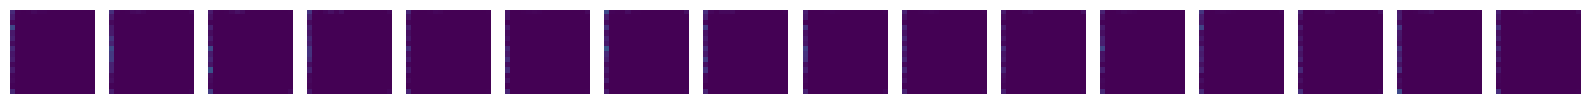

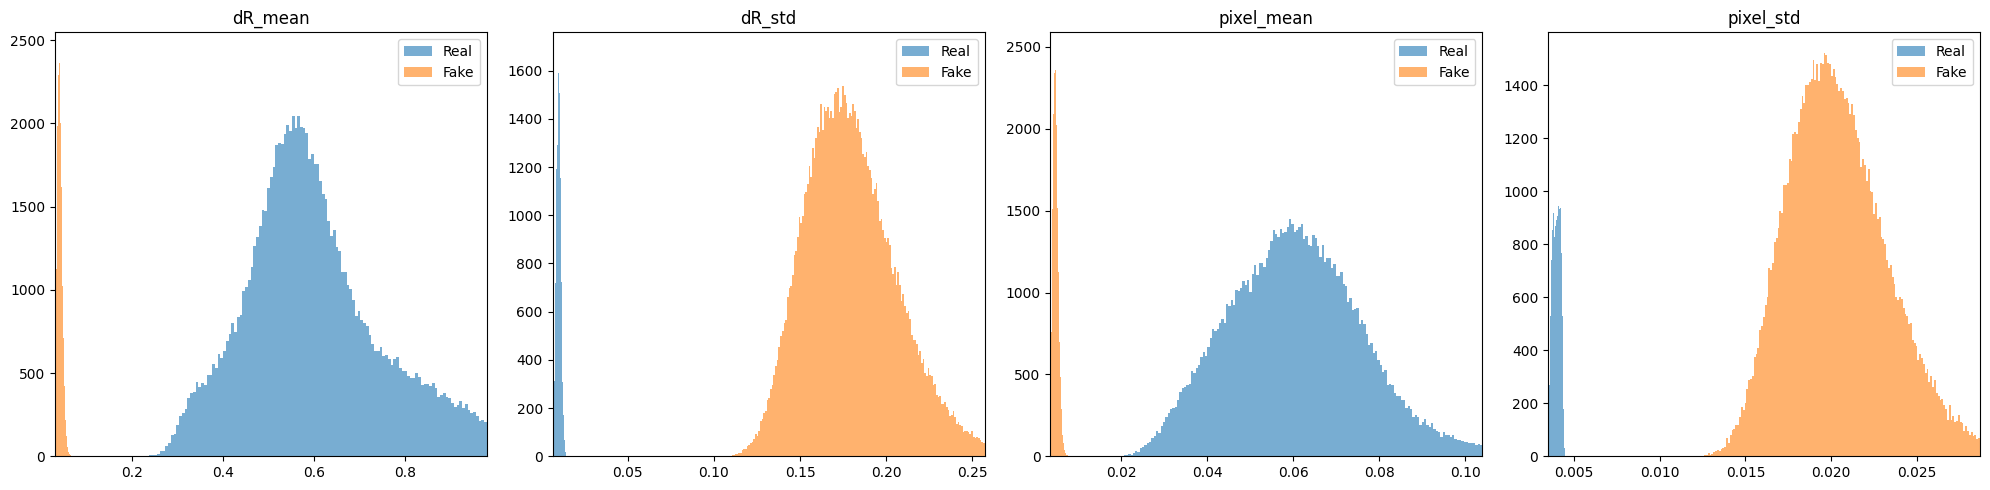

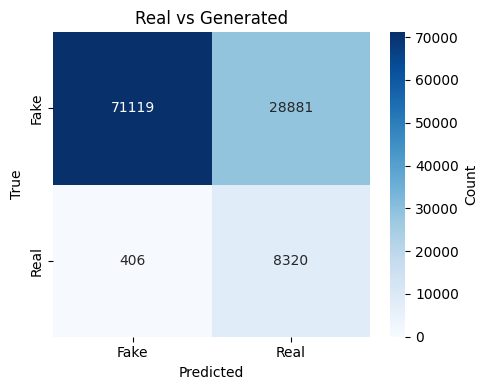

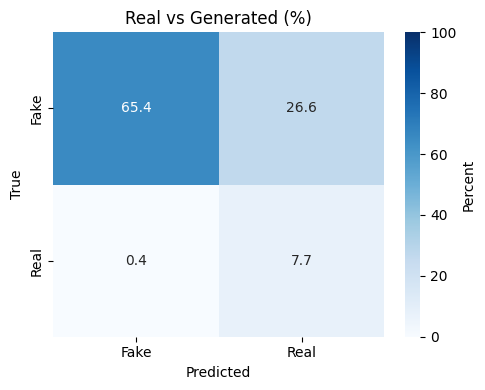

In [7]:
eval_model(model = model, dataset = dataset, sampleloader = sampleloader)

In [8]:
# Training automatically saves the best performing model parameters
# Optionally, save the final model parameters to a custom path
save(model = model, save_path = None)


Saved checkpoint to models/1129_2238.pt


In [9]:
# Or load a previously trained model
load(model = model, load_path = "/models/1129_2158.pt", device = device)

eval_model(model = model, dataset = dataset, sampleloader = sampleloader)

FileNotFoundError: [Errno 2] No such file or directory: '/models/1129_2158.pt'